# Cleaning Data(Kenya Stations)

In [567]:
import pandas as pd
import numpy as np

kenya_stations = pd.read_csv("../Data/kenya_ev_charging_stations_sample.csv")

kenya_stations.head()

,county,station_name,charger_type,connector_types
0,Nairobi,Sarit Centre,AC + DC,"Type2, CHAdeMO"
1,Nairobi,Two Rivers Mall,AC,Type2
2,Nairobi,Village Market Gigiri,AC,Type2
3,Nairobi,Unga House Westlands,AC,Type2
4,Nairobi,Kcb Towers Upper Hill,AC,Type2


# Standardize Columns Names

In [568]:
kenya_stations.columns = (
    kenya_stations.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_")
)

kenya_stations.columns

Index(['county', 'station_name', 'charger_type', 'connector_types'], dtype='object')

# Remove Duplicates


In [569]:
kenya_stations = kenya_stations.drop_duplicates()

kenya_stations.shape

(16, 4)

# Handle Missing Values

In [570]:
kenya_stations.isnull().sum()

county             0
station_name       0
charger_type       0
connector_types    0
dtype: int64

In [571]:
kenya_stations = kenya_stations.rename(columns={
    "county_city": "county"
})


In [572]:
kenya_stations = kenya_stations.dropna(subset=["county"])


# Cleaning Text Columns

In [573]:
kenya_stations["county"] = (
    kenya_stations["county"]
    .astype(str)
    .str.strip()
    .str.title()
)


In [574]:
kenya_stations["station_name"] = (
    kenya_stations["station_name"]
    .astype(str)
    .str.strip()
    .str.title()
)


# Cleaning Charger Type

In [575]:
kenya_stations["charger_type"] = (
    kenya_stations["charger_type"]
    .astype(str)
    .str.strip()
    .str.upper()
)



# Cleaning Connector Types

In [576]:
kenya_stations["connector_types"] = (
    kenya_stations["connector_types"]
    .astype(str)
    .str.strip()
)


# Standardize County Names

In [577]:
kenya_stations["county"] = kenya_stations["county"].str.replace(" County", "")


In [578]:
sorted(kenya_stations["county"].unique())


['Kiambu',
 'Kisumu',
 'Mavoko',
 'Mombasa',
 'Nairobi',
 'Naivasha',
 'Nakuru',
 'Narok']

# Load Population Data

In [579]:
kenya_stations.to_csv("../Data/kenya_ev_charging_stations_sample.csv", index=False)


In [580]:
kenya_stations.columns


Index(['county', 'station_name', 'charger_type', 'connector_types'], dtype='object')

# Cleaning it

In [581]:
# Remove national total row
population = population[population["county"] != "Kenya"]

population.head()


,county,population
1,Mombasa,1208333
2,Kwale,126431
3,Kilifi,393888
4,Tana River,75722
5,Lamu,38446


In [582]:
# Clean stations county names
stations_per_county["county"] = (
    stations_per_county["county"]
    .astype(str)
    .str.strip()
    .str.title()
)

# Clean population county names
population["county"] = (
    population["county"]
    .astype(str)
    .str.strip()
    .str.title()
)


In [583]:
stations_per_county["county"] = stations_per_county["county"].replace({
    "Mavoko": "Machakos",
    "Naivasha": "Nakuru"
})


In [584]:
sorted(stations_per_county["county"].unique())


['Kiambu', 'Kisumu', 'Machakos', 'Mombasa', 'Nairobi', 'Nakuru', 'Narok']

# Ensuring Population is numerical

In [585]:
population["population"] = (
    population["population"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

population["population"] = pd.to_numeric(
    population["population"],
    errors="coerce"
)


In [586]:
population.info()


<class 'pandas.core.frame.DataFrame'>
Index: 47 entries, 1 to 47
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   county      47 non-null     object
 1   population  47 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


In [587]:
# Check if Kenya national row still exists
population[population["county"] == "Kenya"]


,county,population


In [588]:
population = population[population["county"] != "Kenya"]


In [589]:
population = population.rename(columns={
    "County": "county",
    "Total": "population"
})

population["county"] = population["county"].str.strip().str.title()

population = population[["county", "population"]]

population.head()


,county,population
1,Mombasa,1208333
2,Kwale,126431
3,Kilifi,393888
4,Tana River,75722
5,Lamu,38446


# Counting Stations Per County

In [590]:
stations_per_county = (
    kenya_stations.groupby("county")
    .size()
    .reset_index(name="station_count")
)

stations_per_county


,county,station_count
0,Kiambu,1
1,Kisumu,1
2,Mavoko,1
3,Mombasa,1
4,Nairobi,9
5,Naivasha,1
6,Nakuru,1
7,Narok,1


# Merge with Population

In [591]:
population["county"] = (
    population["county"]
        .str.strip()
        .str.title()
)


In [592]:
population["county"] = population["county"].replace({
    "Nairobi City": "Nairobi"
})


In [593]:
stations_per_county["county"] = stations_per_county["county"].replace({
    "Mavoko": "Machakos",
    "Naivasha": "Nakuru"
})


In [594]:
county_data = stations_per_county.merge(
    population,
    on="county",
    how="left"
)

county_data.head()


,county,station_count,population
0,Kiambu,1,1706285
1,Kisumu,1,440906
2,Machakos,1,414078
3,Mombasa,1,1208333
4,Nairobi,9,4397073


# Compute Infrastructure Density

In [595]:
county_data["stations_per_100k"] = (
    county_data["station_count"] /
    county_data["population"]
) * 100000


# Building a NEED SCORE

In [596]:
county_data.sort_values("stations_per_100k", ascending=False)


,county,station_count,population,stations_per_100k
7,Narok,1,100352,0.996492
2,Machakos,1,414078,0.241500
1,Kisumu,1,440906,0.226806
4,Nairobi,9,4397073,0.204682
5,Nakuru,1,1047080,0.095504
6,Nakuru,1,1047080,0.095504
3,Mombasa,1,1208333,0.082759
0,Kiambu,1,1706285,0.058607


# Adding a ranking column

In [597]:
county_data["need_score"] = (
    county_data["population"] /
    (county_data["station_count"] + 1)
)


In [598]:
county_data.sort_values("need_score", ascending=False)


,county,station_count,population,stations_per_100k,need_score
0,Kiambu,1,1706285,0.058607,853142.5
3,Mombasa,1,1208333,0.082759,604166.5
5,Nakuru,1,1047080,0.095504,523540.0
6,Nakuru,1,1047080,0.095504,523540.0
4,Nairobi,9,4397073,0.204682,439707.3
1,Kisumu,1,440906,0.226806,220453.0
2,Machakos,1,414078,0.241500,207039.0
7,Narok,1,100352,0.996492,50176.0


In [599]:
county_data["priority_rank"] = (
    county_data["need_score"]
    .rank(ascending=False)
)


In [600]:
county_data.sort_values("priority_rank")


,county,station_count,population,stations_per_100k,need_score,priority_rank
0,Kiambu,1,1706285,0.058607,853142.5,1.0
3,Mombasa,1,1208333,0.082759,604166.5,2.0
5,Nakuru,1,1047080,0.095504,523540.0,3.5
6,Nakuru,1,1047080,0.095504,523540.0,3.5
4,Nairobi,9,4397073,0.204682,439707.3,5.0
1,Kisumu,1,440906,0.226806,220453.0,6.0
2,Machakos,1,414078,0.241500,207039.0,7.0
7,Narok,1,100352,0.996492,50176.0,8.0


# Basic Statistical Summary

In [601]:
county_data.describe()

,station_count,population,stations_per_100k,need_score,priority_rank
count,8.000000,8.000000e+00,8.000000,8.000000,8.000000
mean,2.000000,1.295148e+06,0.250232,427720.537500,4.500000
std,2.828427,1.355156e+06,0.309897,257688.487468,2.434866
min,1.000000,1.003520e+05,0.058607,50176.000000,1.000000
25%,1.000000,4.341990e+05,0.092317,217099.500000,3.125000
50%,1.000000,1.047080e+06,0.150093,481623.650000,4.250000
75%,1.000000,1.332821e+06,0.230479,543696.625000,6.250000
max,9.000000,4.397073e+06,0.996492,853142.500000,8.000000


In [602]:
county_data.corr(numeric_only=True)


,station_count,population,stations_per_100k,need_score,priority_rank
station_count,1.000000,0.924887,-0.059391,0.018795,0.082974
population,0.924887,1.000000,-0.337685,0.397558,-0.296167
stations_per_100k,-0.059391,-0.337685,1.000000,-0.744606,0.744238
need_score,0.018795,0.397558,-0.744606,1.000000,-0.978983
priority_rank,0.082974,-0.296167,0.744238,-0.978983,1.000000


In [603]:
len(population)


47

In [604]:
len(stations_per_county)


8

In [605]:
county_data = population.merge(
    stations_per_county,
    on="county",
    how="left"
)


In [606]:
county_data["station_count"] = (
    county_data["station_count"]
    .fillna(0)
)


In [607]:
len(county_data)


48

In [608]:
population = population[
    population["county"].str.strip() != "Kenya"
]


In [609]:
len(population)


47

# Rebuilding county_data

In [610]:
county_data = population.merge(
    stations_per_county,
    on="county",
    how="left"
)

county_data["station_count"] = (
    county_data["station_count"]
    .fillna(0)
)


In [611]:
len(county_data)


48

In [612]:
stations_per_county["county"].unique()


array(['Kiambu', 'Kisumu', 'Machakos', 'Mombasa', 'Nairobi', 'Nakuru',
       'Narok'], dtype=object)

In [613]:
population["county"].unique()


array(['Mombasa', 'Kwale', 'Kilifi', 'Tana River', 'Lamu', 'Taita/Taveta',
       'Garissa', 'Wajir', 'Mandera', 'Marsabit', 'Isiolo', 'Meru',
       'Tharaka-Nithi', 'Embu', 'Kitui', 'Machakos', 'Makueni',
       'Nyandarua', 'Nyeri', 'Kirinyaga', "Murang'A", 'Kiambu', 'Turkana',
       'West Pokot', 'Samburu', 'Trans Nzoia', 'Uasin Gishu',
       'Elg Eyo/Marakwet', 'Nandi', 'Baringo', 'Laikipia', 'Nakuru',
       'Narok', 'Kajiado', 'Kericho', 'Bomet', 'Kakamega', 'Vihiga',
       'Bungoma', 'Busia', 'Siaya', 'Kisumu', 'Homa Bay', 'Migori',
       'Kisii', 'Nyamira', 'Nairobi'], dtype=object)

In [614]:
len(population)


47

In [615]:
county_data = population.merge(
    stations_per_county,
    on="county",
    how="left"
)

county_data["station_count"] = (
    county_data["station_count"]
    .fillna(0)
)


In [616]:
len(county_data)


48

In [617]:
county_data[county_data["county"] == "Kenya"]


,county,population,station_count


In [618]:
population.merge(stations_per_county)


,county,population,station_count
0,Mombasa,1208333,1
1,Machakos,414078,1
2,Kiambu,1706285,1
3,Nakuru,1047080,1
4,Nakuru,1047080,1
5,Narok,100352,1
6,Kisumu,440906,1
7,Nairobi,4397073,9


In [619]:
county_data[county_data["county"] == "Kenya"]


,county,population,station_count


In [620]:
stations_per_county[stations_per_county["county"] == "Nakuru"]


,county,station_count
5,Nakuru,1
6,Nakuru,1


In [621]:
stations_per_county = (
    stations_per_county
    .groupby("county", as_index=False)
    .agg({"station_count": "sum"})
)


In [622]:
county_data = population.merge(
    stations_per_county,
    on="county",
    how="left"
)

county_data["station_count"] = (
    county_data["station_count"]
    .fillna(0)
)


In [623]:
len(county_data)


47

# Recalculate Metrics(Because We Rebuilt)

In [624]:
county_data["stations_per_100k"] = (
    county_data["station_count"] / county_data["population"]
) * 100000


In [625]:
county_data["need_score"] = (
    county_data["population"] / (county_data["station_count"] + 1)
)


In [626]:
county_data["priority_rank"] = (
    county_data["need_score"]
    .rank(ascending=False)
)


In [627]:
county_data.sort_values("priority_rank").head(10)


,county,population,station_count,stations_per_100k,need_score,priority_rank
21,Kiambu,1706285,1.0,0.058607,853142.500000,1.0
33,Kajiado,622622,0.0,0.000000,622622.000000,2.0
0,Mombasa,1208333,1.0,0.082759,604166.500000,3.0
26,Uasin Gishu,510205,0.0,0.000000,510205.000000,4.0
46,Nairobi,4397073,9.0,0.204682,439707.300000,5.0
2,Kilifi,393888,0.0,0.000000,393888.000000,6.0
31,Nakuru,1047080,2.0,0.191007,349026.666667,7.0
8,Mandera,270467,0.0,0.000000,270467.000000,8.0
41,Kisumu,440906,1.0,0.226806,220453.000000,9.0
6,Garissa,210890,0.0,0.000000,210890.000000,10.0


# EDA
# Distributions of stations Across Counties

In [628]:
%matplotlib inline


Text(0, 0.5, 'Number of Counties')

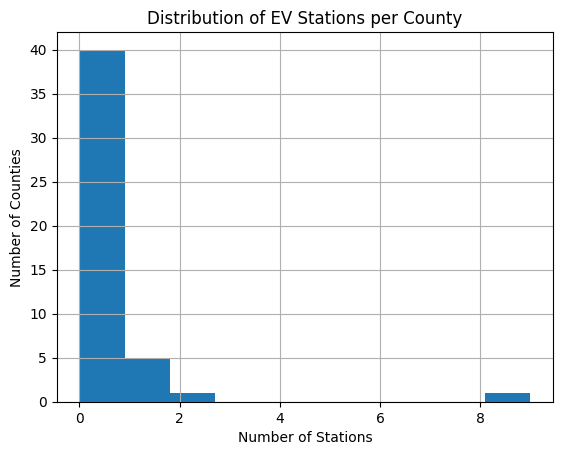

In [629]:
plt.figure()
county_data["station_count"].hist()
plt.title("Distribution of EV Stations per County")
plt.xlabel("Number of Stations")
plt.ylabel("Number of Counties")


# How many counties have zero stations

In [630]:
(county_data["station_count"] == 0).sum()


np.int64(40)

In [631]:
(county_data["station_count"] == 0).mean() * 100


np.float64(85.1063829787234)

Text(0.5, 1.0, 'Stations vs Population')

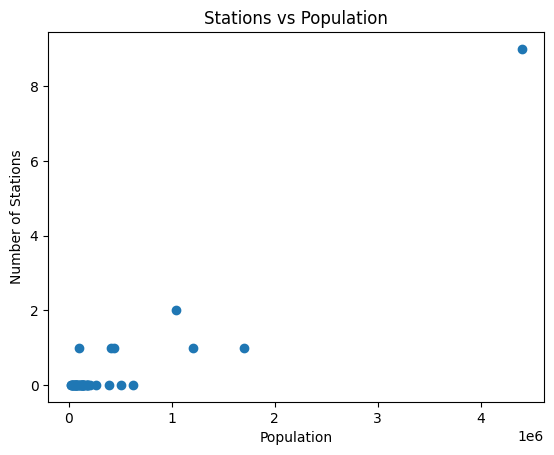

In [632]:
plt.figure()
plt.scatter(county_data["population"], county_data["station_count"])
plt.xlabel("Population")
plt.ylabel("Number of Stations")
plt.title("Stations vs Population")


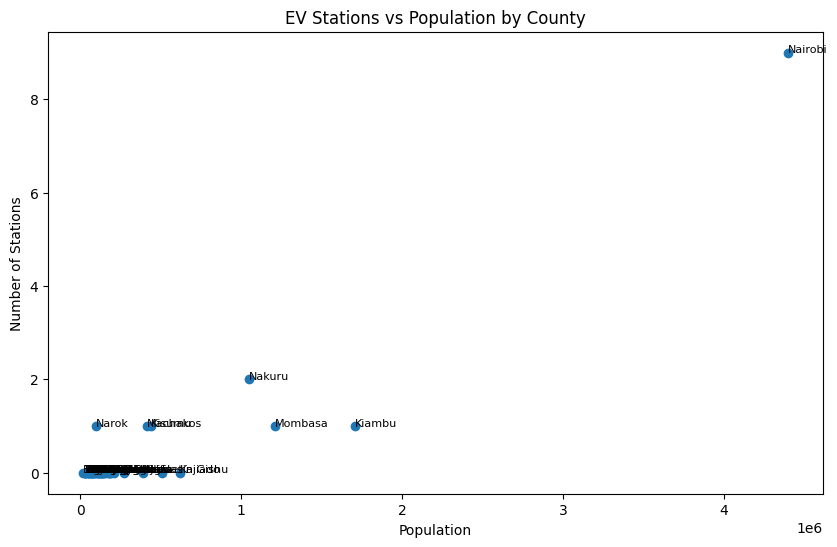

In [633]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(county_data["population"], county_data["station_count"])

for i, row in county_data.iterrows():
    plt.text(row["population"], row["station_count"], row["county"], fontsize=8)

plt.xlabel("Population")
plt.ylabel("Number of Stations")
plt.title("EV Stations vs Population by County")

plt.show()


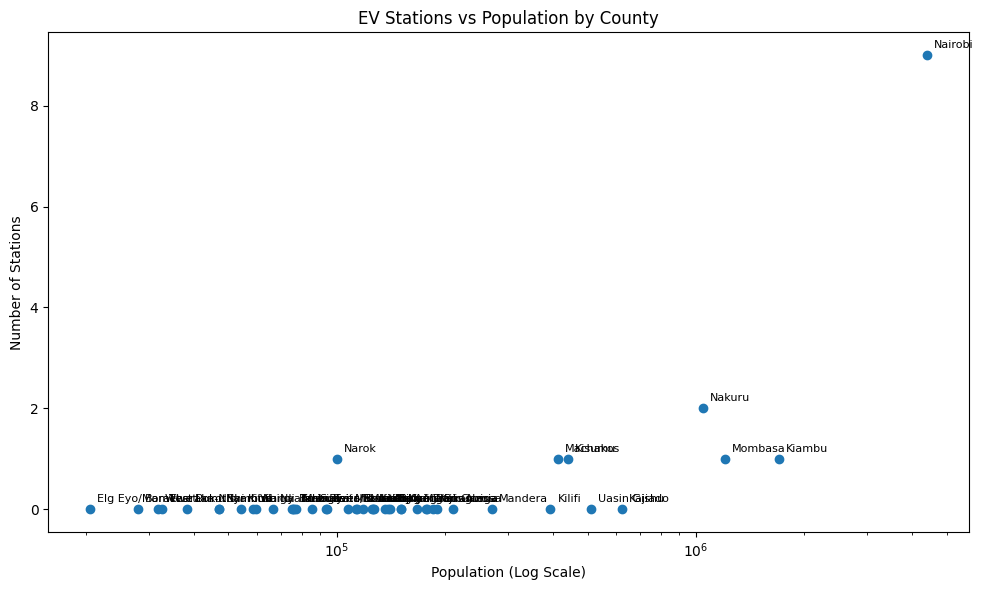

In [634]:
plt.figure(figsize=(10,6))

plt.scatter(
    county_data["population"],
    county_data["station_count"]
)

for _, row in county_data.iterrows():
    plt.annotate(
        row["county"],
        (row["population"], row["station_count"]),
        xytext=(5,5),
        textcoords="offset points",
        fontsize=8
    )

plt.xscale("log")

plt.xlabel("Population (Log Scale)")
plt.ylabel("Number of Stations")
plt.title("EV Stations vs Population by County")

plt.tight_layout()
plt.show()


# Demand vs Infrastructure Gap Analysis

In [635]:
county_data.columns


Index(['county', 'population', 'station_count', 'stations_per_100k',
       'need_score', 'priority_rank'],
      dtype='object')

# Top 10 High-Demand Counties (BAR CHART)

In [636]:
# Normalize population as proxy for urbanization
county_data["urban_rate"] = (
    county_data["population"] - county_data["population"].min()
) / (
    county_data["population"].max() - county_data["population"].min()
)


In [637]:
county_data["income_index"] = county_data["urban_rate"]


In [638]:
county_data["EV_Demand_Index"] = (
    county_data["population"] *
    county_data["urban_rate"] *
    county_data["income_index"]
)


In [639]:
county_data[["county", "EV_Demand_Index"]].head()


,county,EV_Demand_Index
0,Mombasa,88999.376659
1,Kwale,73.960363
2,Kilifi,2865.873363
3,Tana River,12.021265
4,Lamu,0.640769


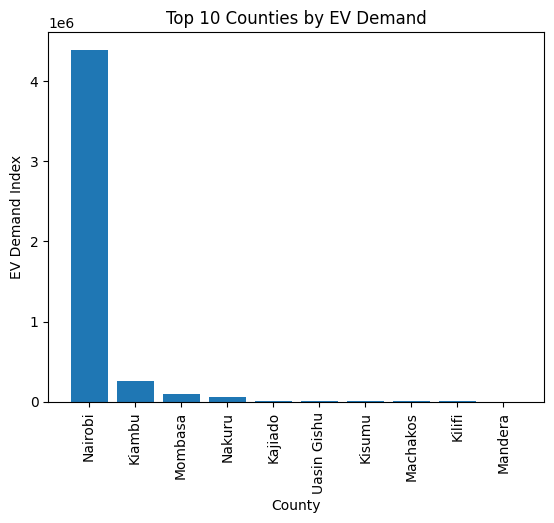

In [640]:
top_demand = county_data.sort_values(
    by="EV_Demand_Index",
    ascending=False
).head(10)

plt.figure()
plt.bar(top_demand["county"], top_demand["EV_Demand_Index"])
plt.xticks(rotation=90)
plt.title("Top 10 Counties by EV Demand")
plt.xlabel("County")
plt.ylabel("EV Demand Index")
plt.show()


# Counties With Zero Stations

In [641]:
zero_stations = county_data[county_data["station_count"] == 0]

len(zero_stations)


40

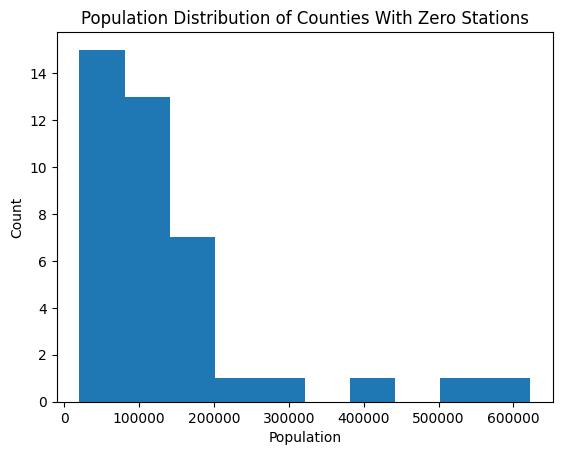

In [642]:
plt.figure()
plt.hist(zero_stations["population"])
plt.title("Population Distribution of Counties With Zero Stations")
plt.xlabel("Population")
plt.ylabel("Count")
plt.show()


# Correlation Matrix

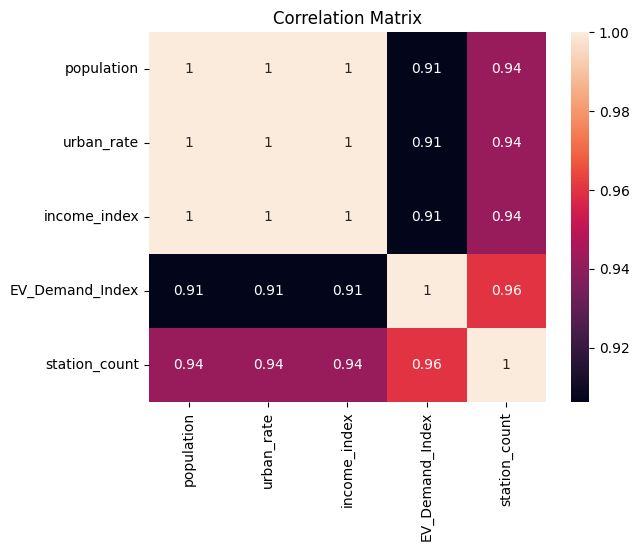

In [643]:
import seaborn as sns

plt.figure()
sns.heatmap(
    county_data[[
        "population",
        "urban_rate",
        "income_index",
        "EV_Demand_Index",
        "station_count"
    ]].corr(),
    annot=True
)
plt.title("Correlation Matrix")
plt.show()


# Demand Per Station Ratio (Investment Pressure)

In [644]:
county_data["Demand_per_Station"] = (
    county_data["EV_Demand_Index"] /
    (county_data["station_count"] + 1)
)

county_data.sort_values(
    by="Demand_per_Station",
    ascending=False
).head(10)


,county,population,station_count,stations_per_100k,need_score,priority_rank,urban_rate,income_index,EV_Demand_Index,Demand_per_Station
46,Nairobi,4397073,9.0,0.204682,439707.300000,5.0,1.000000,1.000000,4.397073e+06,439707.300000
21,Kiambu,1706285,1.0,0.058607,853142.500000,1.0,0.385173,0.385173,2.531410e+05,126570.520965
0,Mombasa,1208333,1.0,0.082759,604166.500000,3.0,0.271394,0.271394,8.899938e+04,44499.688330
31,Nakuru,1047080,2.0,0.191007,349026.666667,7.0,0.234549,0.234549,5.760311e+04,19201.037172
33,Kajiado,622622,0.0,0.000000,622622.000000,2.0,0.137563,0.137563,1.178221e+04,11782.211373
26,Uasin Gishu,510205,0.0,0.000000,510205.000000,4.0,0.111876,0.111876,6.385883e+03,6385.883314
2,Kilifi,393888,0.0,0.000000,393888.000000,6.0,0.085299,0.085299,2.865873e+03,2865.873363
41,Kisumu,440906,1.0,0.226806,220453.000000,9.0,0.096042,0.096042,4.066941e+03,2033.470679
15,Machakos,414078,1.0,0.241500,207039.000000,11.0,0.089912,0.089912,3.347470e+03,1673.735211
8,Mandera,270467,0.0,0.000000,270467.000000,8.0,0.057098,0.057098,8.817641e+02,881.764097


# Modeling

In [645]:
county_data["Ev_Demand_Index"] = county_data["population"]


In [646]:
county_data["population_log"] = np.log1p(county_data["population"])


# Preparing Data for ML

In [647]:
county_data.columns


Index(['county', 'population', 'station_count', 'stations_per_100k',
       'need_score', 'priority_rank', 'urban_rate', 'income_index',
       'EV_Demand_Index', 'Demand_per_Station', 'Ev_Demand_Index',
       'population_log'],
      dtype='object')

In [648]:
county_data["EV_Demand_Index"] = county_data["population"]


In [649]:
county_data.head()


,county,population,station_count,stations_per_100k,need_score,priority_rank,urban_rate,income_index,EV_Demand_Index,Demand_per_Station,Ev_Demand_Index,population_log
0,Mombasa,1208333,1.0,0.082759,604166.5,3.0,0.271394,0.271394,1208333,44499.688330,1208333,14.004753
1,Kwale,126431,0.0,0.000000,126431.0,23.0,0.024186,0.024186,126431,73.960363,126431,11.747460
2,Kilifi,393888,0.0,0.000000,393888.0,6.0,0.085299,0.085299,393888,2865.873363,393888,12.883824
3,Tana River,75722,0.0,0.000000,75722.0,34.0,0.012600,0.012600,75722,12.021265,75722,11.234837
4,Lamu,38446,0.0,0.000000,38446.0,43.0,0.004082,0.004082,38446,0.640769,38446,10.557036


In [650]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Features
X = county_data[["population_log"]]

# Target
y = county_data["EV_Demand_Index"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Training the Model

In [651]:
# Train model
model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [652]:
# Predictions
y_pred = model.predict(X_test)


In [653]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)


Mean Absolute Error: 4622.627999999995
R² Score: 0.9971111940538184


In [654]:
X = county_data[[
    "population_log",
    "stations_per_100k",
    "station_count"
]]


In [655]:
county_data["EV_Demand_Index"] = (
    0.6 * county_data["population"] +
    0.3 * county_data["population"] * county_data["stations_per_100k"] +
    0.1 * county_data["station_count"]
)


In [656]:
X = county_data[[
    "population_log",
    "stations_per_100k",
    "station_count"
]]

y = county_data["EV_Demand_Index"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))


MAE: 2634.26800000004
R2: 0.9976607154943599


In [657]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)


population_log       0.821124
station_count        0.168436
stations_per_100k    0.010439
dtype: float64


# creating synthetic Urbanization Rate

In [658]:
# Create urbanization rate column
urban_counties = ["Nairobi", "Mombasa", "Kiambu", "Nakuru", "Kisumu"]

county_data["urban_rate"] = 0.25  # default rural/semi-urban

county_data.loc[
    county_data["county"].isin(urban_counties),
    "urban_rate"
] = 0.65


# Creating Synthetic Income Index

In [659]:
# Normalize population into 0–1 scale
county_data["income_index"] = (
    county_data["population"] - county_data["population"].min()
) / (
    county_data["population"].max() - county_data["population"].min()
)


# Creating Improved EV Demand Index

In [660]:
county_data["EV_Demand_log"] = np.log1p(
    county_data["EV_Demand_Index"]
)


In [661]:
X = county_data[[
    "population_log",
    "urban_rate",
    "income_index",
    "stations_per_100k"
]]

y = county_data["EV_Demand_log"]


In [662]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [663]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [664]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)


Mean Absolute Error: 0.06345892382742643
R² Score: 0.9840034727464387


In [665]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance


,feature,importance
0,population_log,0.522219
2,income_index,0.442240
1,urban_rate,0.022597
3,stations_per_100k,0.012943


In [666]:
county_data["Priority_Score"] = (
    county_data["EV_Demand_Index"] /
    (county_data["station_count"] + 1)
)

county_data.sort_values(
    by="Priority_Score",
    ascending=False
).head(10)


,county,population,station_count,stations_per_100k,need_score,priority_rank,urban_rate,income_index,EV_Demand_Index,Demand_per_Station,Ev_Demand_Index,population_log,EV_Demand_log,Priority_Score
21,Kiambu,1706285,1.0,0.058607,853142.500000,1.0,0.65,0.385173,1053771.1,126570.520965,1706285,14.349830,13.867887,526885.550000
0,Mombasa,1208333,1.0,0.082759,604166.500000,3.0,0.65,0.271394,754999.9,44499.688330,1208333,14.004753,13.534474,377499.950000
33,Kajiado,622622,0.0,0.000000,622622.000000,2.0,0.25,0.137563,373573.2,11782.211373,622622,13.341696,12.830872,373573.200000
26,Uasin Gishu,510205,0.0,0.000000,510205.000000,4.0,0.25,0.111876,306123.0,6385.883314,510205,13.142570,12.631746,306123.000000
46,Nairobi,4397073,9.0,0.204682,439707.300000,5.0,0.65,1.000000,2908244.7,439707.300000,4397073,15.296450,14.883061,290824.470000
2,Kilifi,393888,0.0,0.000000,393888.000000,6.0,0.25,0.085299,236332.8,2865.873363,393888,12.883824,12.373000,236332.800000
31,Nakuru,1047080,2.0,0.191007,349026.666667,7.0,0.65,0.234549,688248.2,19201.037172,1047080,13.861517,13.441906,229416.066667
8,Mandera,270467,0.0,0.000000,270467.000000,8.0,0.25,0.057098,162280.2,881.764097,270467,12.507909,11.997086,162280.200000
41,Kisumu,440906,1.0,0.226806,220453.000000,9.0,0.65,0.096042,294543.7,2033.470679,440906,12.996589,12.593186,147271.850000
15,Machakos,414078,1.0,0.241500,207039.000000,11.0,0.25,0.089912,278446.9,1673.735211,414078,12.933812,12.536986,139223.450000
